In [113]:
pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [114]:
import mysql.connector
import pandas as pd
import numpy as np

# Connect to server
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="2004")

In [115]:
query = "SELECT * FROM banking_project.banking"
df = pd.read_sql(query, cnx)

C:\Users\mohit\AppData\Local\Temp\ipykernel_16552\2245758346.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


In [116]:
df.head(10)

,ï»¿account_id,customer_name,account_type,branch,transaction_type,transaction_amount,account_balance,currency
0,ACC00001,Amanda Pugh,Recurring Deposit,New York,Debit,2687.19,36676.19,GBP
1,ACC00002,Amanda Wilcox,Recurring Deposit,Houston,Debit,3886.77,28582.82,
2,ACC00003,Kimberly Valenzuela,Current,New York,Credit,2438.74,76599.56,GBP
3,ACC00004,Sonia Ballard,Recurring Deposit,Philadelphia,Credit,2758.53,62317.60,INR
4,ACC00005,Erika Russell,Current,Philadelphia,Debit,3287.00,85515.21,INR
5,ACC00006,William Sanchez,Savings,New York,Debit,143.50,43853.88,INR
6,ACC00007,Virginia Sanchez,Savings,New York,Debit,3048.44,8712.06,USD
7,ACC00008,David Martin,Fixed Deposit,San Diego,Debit,3157.34,41826.02,GBP
8,ACC00009,Molly Riley,Current,Philadelphia,Debit,198.08,99240.82,INR
9,ACC00010,Alex Chaney,Current,New York,Credit,983.58,67885.77,EUR


In [117]:
df.notnull()

,ï»¿account_id,customer_name,account_type,branch,transaction_type,transaction_amount,account_balance,currency
0,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...
9995,True,True,True,True,True,True,True,True
9996,True,True,True,True,True,True,True,True
9997,True,True,True,True,True,True,True,True
9998,True,True,True,True,True,True,True,True


In [118]:
df['currency'].unique()

array(['GBP', '', 'INR', 'USD', 'EUR', 'JPY'], dtype=object)

In [119]:
df['currency'] = df['currency'].replace('', np.nan) # replacing '' this nan

In [120]:
df.head(10)

,ï»¿account_id,customer_name,account_type,branch,transaction_type,transaction_amount,account_balance,currency
0,ACC00001,Amanda Pugh,Recurring Deposit,New York,Debit,2687.19,36676.19,GBP
1,ACC00002,Amanda Wilcox,Recurring Deposit,Houston,Debit,3886.77,28582.82,NaN
2,ACC00003,Kimberly Valenzuela,Current,New York,Credit,2438.74,76599.56,GBP
3,ACC00004,Sonia Ballard,Recurring Deposit,Philadelphia,Credit,2758.53,62317.60,INR
4,ACC00005,Erika Russell,Current,Philadelphia,Debit,3287.00,85515.21,INR
5,ACC00006,William Sanchez,Savings,New York,Debit,143.50,43853.88,INR
6,ACC00007,Virginia Sanchez,Savings,New York,Debit,3048.44,8712.06,USD
7,ACC00008,David Martin,Fixed Deposit,San Diego,Debit,3157.34,41826.02,GBP
8,ACC00009,Molly Riley,Current,Philadelphia,Debit,198.08,99240.82,INR
9,ACC00010,Alex Chaney,Current,New York,Credit,983.58,67885.77,EUR


In [121]:
df['currency'] = df['currency'].fillna('USD') #filling null values

In [122]:
df.head(2)

,ï»¿account_id,customer_name,account_type,branch,transaction_type,transaction_amount,account_balance,currency
0,ACC00001,Amanda Pugh,Recurring Deposit,New York,Debit,2687.19,36676.19,GBP
1,ACC00002,Amanda Wilcox,Recurring Deposit,Houston,Debit,3886.77,28582.82,USD


In [123]:
df.isnull().sum()

ï»¿account_id         0
customer_name         0
account_type          0
branch                0
transaction_type      0
transaction_amount    0
account_balance       0
currency              0
dtype: int64

In [124]:
df.rename(columns={'ï»¿account_id': 'account_id',}, inplace=True) # renaming columns

In [125]:
df.rename(columns={'account_iD': 'account_id',}, inplace=True)

In [126]:
# adding transaction date column
df['transaction_date'] = pd.to_datetime(
    np.random.choice(
        pd.date_range(start='2022-01-01', end='2024-12-31'),
        size=len(df)
    )
)

In [127]:
# addding other relevant columns
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B')
df['day'] = df['transaction_date'].dt.day
df['weekday'] = df['transaction_date'].dt.day_name()

In [128]:
# adding trasaction direction columns 
df['transaction_direction'] = df['transaction_type'].apply(
    lambda x: 'Inflow' if x.lower() == 'credit' else 'Outflow'
)

In [129]:
# adding trasansaction category 
import random
categories = ['Food', 'Shopping', 'Bills', 'Salary', 'Transfer', 'Entertainment']
df['transaction_category'] = np.random.choice(categories, size=len(df))

In [130]:
df['net_amount'] = df.apply(
    lambda row: row['transaction_amount'] if row['transaction_type'].lower() == 'credit'
    else -row['transaction_amount'], axis=1
)

In [131]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 1. Uneven Transaction Type
df['transaction_type'] = np.random.choice(
    ['Credit', 'Debit'],
    size=len(df),
    p=[0.35, 0.65]
)

# 2. Realistic Transaction Amount (skewed distribution)
df['transaction_amount'] = np.random.gamma(shape=2, scale=2000, size=len(df)).round(2)

# 3. Transaction Category (uneven)
categories = ['Food', 'Shopping', 'Bills', 'Salary', 'Transfer']
df['transaction_category'] = np.random.choice(
    categories,
    size=len(df),
    p=[0.30, 0.25, 0.20, 0.10, 0.15]
)

# 4. Recalculate Transaction Direction
df['transaction_direction'] = df['transaction_type'].apply(
    lambda x: 'Inflow' if x == 'Credit' else 'Outflow'
)

# 5. Recalculate Net Amount
df['net_amount'] = np.where(
    df['transaction_type'] == 'Credit',
    df['transaction_amount'],
    -df['transaction_amount']
)

# 6. Make Branch activity uneven
df['branch'] = np.random.choice(
    df['branch'].unique(),
    size=len(df),
    p=np.random.dirichlet(np.ones(len(df['branch'].unique())))
)

# 7. Add weekend effect (more spending on weekends)
df.loc[df['weekday'].isin(['Saturday', 'Sunday']), 'transaction_amount'] *= 1.3

# 8. Salary logic (higher credit at start of month)
df.loc[(df['day'] <= 5) & (df['transaction_type'] == 'Credit'), 'transaction_amount'] *= 2

# 9. Round values
df['transaction_amount'] = df['transaction_amount'].round(2)
df['net_amount'] = df['net_amount'].round(2)

In [132]:
df.head(10)

,account_id,customer_name,account_type,branch,transaction_type,transaction_amount,account_balance,currency,transaction_date,year,month,month_name,day,weekday,transaction_direction,transaction_category,net_amount
0,ACC00001,Amanda Pugh,Recurring Deposit,Los Angeles,Debit,778.53,36676.19,GBP,2024-01-03,2024,1,January,3,Wednesday,Outflow,Transfer,-778.53
1,ACC00002,Amanda Wilcox,Recurring Deposit,Phoenix,Debit,1190.41,28582.82,USD,2022-09-27,2022,9,September,27,Tuesday,Outflow,Food,-1190.41
2,ACC00003,Kimberly Valenzuela,Current,Houston,Debit,7110.48,76599.56,GBP,2022-07-20,2022,7,July,20,Wednesday,Outflow,Bills,-7110.48
3,ACC00004,Sonia Ballard,Recurring Deposit,Phoenix,Debit,3153.05,62317.60,INR,2024-04-03,2024,4,April,3,Wednesday,Outflow,Food,-3153.05
4,ACC00005,Erika Russell,Current,San Diego,Credit,5753.50,85515.21,INR,2024-07-09,2024,7,July,9,Tuesday,Inflow,Bills,5753.50
5,ACC00006,William Sanchez,Savings,Phoenix,Credit,11583.80,43853.88,INR,2022-08-02,2022,8,August,2,Tuesday,Inflow,Salary,5791.90
6,ACC00007,Virginia Sanchez,Savings,Phoenix,Credit,5630.32,8712.06,USD,2024-07-02,2024,7,July,2,Tuesday,Inflow,Shopping,2815.16
7,ACC00008,David Martin,Fixed Deposit,Phoenix,Debit,6419.96,41826.02,GBP,2022-05-22,2022,5,May,22,Sunday,Outflow,Transfer,-4938.43
8,ACC00009,Molly Riley,Current,Chicago,Debit,3475.29,99240.82,INR,2024-01-14,2024,1,January,14,Sunday,Outflow,Salary,-2673.30
9,ACC00010,Alex Chaney,Current,Philadelphia,Debit,2972.68,67885.77,EUR,2022-08-20,2022,8,August,20,Saturday,Outflow,Food,-2286.68


In [133]:
df.describe()

,transaction_amount,account_balance,transaction_date,year,month,day,net_amount
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4610.940475,50269.794260,2023-07-04 02:20:32.640000,2023.005000,6.521100,15.846600,-1175.831268
min,11.050000,101.890000,2022-01-01 00:00:00,2022.000000,1.000000,1.000000,-27389.320000
25%,2125.102500,24863.487500,2022-10-07 00:00:00,2022.000000,3.000000,8.000000,-4132.902500
50%,3712.620000,50790.475000,2023-07-10 00:00:00,2023.000000,7.000000,16.000000,-1793.200000
75%,6108.965000,75128.187500,2024-03-28 00:00:00,2024.000000,10.000000,23.000000,2146.415000
max,42494.010000,99975.590000,2024-12-31 00:00:00,2024.000000,12.000000,31.000000,20435.190000
std,3519.461794,29057.726646,NaN,0.811937,3.472688,8.806431,4774.648822


In [134]:
df['transaction_type'].value_counts()

transaction_type
Debit     6445
Credit    3555
Name: count, dtype: int64

In [135]:
df['branch'].value_counts()

branch
Phoenix         5470
Chicago         1396
San Diego        868
Los Angeles      801
Houston          628
Philadelphia     489
New York         271
San Antonio       77
Name: count, dtype: int64

In [136]:
df.groupby('weekday')['transaction_amount'].sum().sort_values()

weekday
Wednesday    5829356.41
Monday       6048245.59
Tuesday      6110206.28
Thursday     6140303.25
Friday       6202347.66
Sunday       7857078.31
Saturday     7921867.25
Name: transaction_amount, dtype: float64

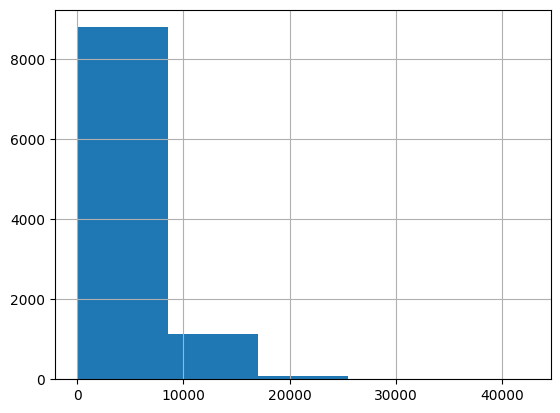

In [141]:
import matplotlib.pyplot as plt

df['transaction_amount'].hist(bins=5)
plt.show()

In [142]:
df[['transaction_type', 'transaction_amount', 'net_amount']].head(10)

,transaction_type,transaction_amount,net_amount
0,Debit,778.53,-778.53
1,Debit,1190.41,-1190.41
2,Debit,7110.48,-7110.48
3,Debit,3153.05,-3153.05
4,Credit,5753.50,5753.50
5,Credit,11583.80,5791.90
6,Credit,5630.32,2815.16
7,Debit,6419.96,-4938.43
8,Debit,3475.29,-2673.30
9,Debit,2972.68,-2286.68


In [143]:
df.to_csv('banking_dataset_final.csv', index=False)